# 06 — Demand Forecasting (ARIMA + ETS)
**Project:** Spatial–Temporal Analysis and Demand Forecasting of Ride-Hailing Mobility

**Purpose:** Train per-zone short-term forecasting models on hourly ride demand. Two families:
* **ARIMA / SARIMA** — captures autoregressive structure + daily seasonality (m=24)
* **ETS (Holt-Winters)** — error-trend-seasonality decomposition with additive components

**Output:**
* Trained models exported as `.pkl` → `models/arima_zone_{id}.pkl`, `models/ets_zone_{id}.pkl` (loaded by the Spark Forecasting job)
* Forecast predictions written to PostgreSQL `forecast_results` hypertable
* Evaluation report (MAE / RMSE / MAPE) saved to `outputs/forecasting/`

**Tables used:** `hourly_demand`, `taxi_zones`  →  writes `forecast_results`

## 0 · Setup

In [4]:
!pip install statsmodels pmdarima sqlalchemy psycopg2-binary joblib -q

In [5]:
import os
import warnings
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text

import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']

os.makedirs('outputs/forecasting', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Setup complete.')

Setup complete.


In [6]:
# ── Database connection ─────────────────────────────────────
PG_HOST = '2.tcp.ngrok.io'
PG_PORT = 28535
PG_DB   = 'rides'
PG_USER = 'rides'
PG_PASS = 'rides'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True,
)

with engine.connect() as conn:
    n = conn.execute(text('SELECT COUNT(*) FROM hourly_demand')).scalar()
    span = conn.execute(text(
        'SELECT MIN(time_bucket), MAX(time_bucket) FROM hourly_demand'
    )).fetchone()
    print(f'hourly_demand rows: {n:,}')
    print(f'Time span: {span[0]}  →  {span[1]}')

hourly_demand rows: 13,782
Time span: 2026-05-15 18:00:00+00:00  →  2026-05-22 21:00:00+00:00


## 1 · Select Top Zones & Load Hourly Demand

Forecasting all 263 zones is wasteful — most zones average < 5 trips/hr and the resulting series are too noisy for meaningful prediction. We focus on the top 20 zones by total demand.

The forecast window is 7 days. We train on the preceding 30 days (720 hourly points), which gives enough history for SARIMA to learn weekly patterns while keeping `auto_arima` fast.

In [7]:
# Pick top N zones by total demand
TOP_N        = 10
TRAIN_DAYS   = 5
TEST_DAYS    = 2
HORIZON      = TEST_DAYS * 24

top_zones_sql = f"""
SELECT
    hd.zone_id,
    z.zone_name,
    z.borough,
    SUM(hd.pickup_count) AS total_pickups
FROM hourly_demand hd
JOIN taxi_zones z ON z.zone_id = hd.zone_id
WHERE z.borough != 'Unknown'
GROUP BY hd.zone_id, z.zone_name, z.borough
ORDER BY total_pickups DESC
LIMIT {TOP_N}
"""
top_zones = pd.read_sql(top_zones_sql, engine)
print(f'Selected {len(top_zones)} zones for forecasting')
print(top_zones.to_string(index=False))

Selected 10 zones for forecasting
 zone_id                 zone_name   borough  total_pickups
     138         LaGuardia Airport    Queens          37420
     132               JFK Airport    Queens          36227
     161            Midtown Center Manhattan          22279
      61       Crown Heights North  Brooklyn          21650
     230 Times Sq/Theatre District Manhattan          20470
      76             East New York  Brooklyn          19668
     246 West Chelsea/Hudson Yards Manhattan          18590
      68              East Chelsea Manhattan          18494
     231      TriBeCa/Civic Center Manhattan          18068
      79              East Village Manhattan          17583


In [8]:
# Pull hourly_demand for those zones over (TRAIN_DAYS + TEST_DAYS)
zone_ids = top_zones['zone_id'].tolist()
zone_id_csv = ','.join(map(str, zone_ids))

demand_sql = f"""
SELECT
    time_bucket,
    zone_id,
    pickup_count
FROM hourly_demand
WHERE zone_id IN ({zone_id_csv})
  AND time_bucket > (
      SELECT MAX(time_bucket) - INTERVAL '{TRAIN_DAYS + TEST_DAYS} days'
      FROM hourly_demand
  )
ORDER BY zone_id, time_bucket
"""
demand_df = pd.read_sql(demand_sql, engine, parse_dates=['time_bucket'])
print(f'Loaded {len(demand_df):,} rows')

# Pivot to wide: index=hour, columns=zone_id, values=pickup_count
wide = demand_df.pivot(index='time_bucket', columns='zone_id', values='pickup_count')

# Ensure hourly frequency, forward-fill short gaps (max 2 hours)
wide = wide.asfreq('h').ffill(limit=2).fillna(0)
print(f'Wide matrix: {wide.shape}  ({wide.index.min()} → {wide.index.max()})')

Loaded 540 rows
Wide matrix: (143, 10)  (2026-05-16 23:00:00+00:00 → 2026-05-22 21:00:00+00:00)


## 2 · Train / Test Split

In [9]:
split_idx = len(wide) - HORIZON
train     = wide.iloc[:split_idx]
test      = wide.iloc[split_idx:]

print(f'Train: {len(train)} hours  ({train.index.min()} → {train.index.max()})')
print(f'Test:  {len(test)} hours  ({test.index.min()} → {test.index.max()})')

Train: 95 hours  (2026-05-16 23:00:00+00:00 → 2026-05-20 21:00:00+00:00)
Test:  48 hours  (2026-05-20 22:00:00+00:00 → 2026-05-22 21:00:00+00:00)


## 3 · ARIMA / SARIMA per Zone

`pmdarima.auto_arima` searches over (p,d,q)(P,D,Q,m) with m=24 (daily seasonality). To keep fitting time reasonable on Colab, we restrict the search space and use `stepwise=True`.

Weekly seasonality (m=168) is excluded — SARIMA degrades badly at long seasonal periods and would take 30+ min per zone. Weekly patterns are picked up by ETS instead.

In [10]:
def fit_arima(y, m=24):
    """Auto-fit a (S)ARIMA model and return the fitted object."""
    return pm.auto_arima(
        y,
        seasonal=True, m=m,
        max_p=3, max_q=3, max_P=1, max_Q=1, max_D=1,
        d=None, D=None,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        information_criterion='aic',
    )

arima_models = {}
arima_preds  = {}
arima_times  = {}

for zid in zone_ids:
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    y_train = train[zid].astype(float)
    if y_train.sum() < 20:
        print(f'  zone {zid} ({name}): insufficient demand, skipping')
        continue

    t0 = time.time()
    try:
        model = fit_arima(y_train)
        fc, conf = model.predict(n_periods=HORIZON, return_conf_int=True, alpha=0.05)
        arima_models[zid] = model
        arima_preds[zid]  = pd.DataFrame({
            'forecast':    fc,
            'lower':       conf[:, 0],
            'upper':       conf[:, 1],
        }, index=test.index)
        elapsed = time.time() - t0
        arima_times[zid] = elapsed
        print(f'  zone {zid:3d} ({name[:25]:25s}): order={model.order} '
              f'seasonal={model.seasonal_order} AIC={model.aic():.1f}  ({elapsed:.1f}s)')
    except Exception as e:
        print(f'  zone {zid} ({name}): FAILED — {type(e).__name__}: {e}')

print(f'\nARIMA fits: {len(arima_models)}/{len(zone_ids)} '
      f'  total time: {sum(arima_times.values()):.1f}s')

  zone 138 (LaGuardia Airport        ): order=(1, 1, 0) seasonal=(0, 0, 1, 24) AIC=1236.4  (19.3s)
  zone 132 (JFK Airport              ): order=(2, 1, 2) seasonal=(0, 1, 1, 24) AIC=904.4  (25.6s)
  zone 161 (Midtown Center           ): order=(1, 1, 0) seasonal=(0, 1, 0, 24) AIC=801.9  (3.3s)
  zone  61 (Crown Heights North      ): order=(0, 1, 2) seasonal=(1, 0, 0, 24) AIC=1026.4  (10.5s)
  zone 230 (Times Sq/Theatre District): order=(0, 1, 2) seasonal=(0, 0, 0, 24) AIC=1032.9  (7.2s)
  zone  76 (East New York            ): order=(1, 1, 0) seasonal=(0, 0, 1, 24) AIC=1011.3  (5.7s)
  zone 246 (West Chelsea/Hudson Yards): order=(0, 1, 3) seasonal=(0, 0, 0, 24) AIC=1027.3  (11.0s)
  zone  68 (East Chelsea             ): order=(0, 1, 0) seasonal=(0, 0, 0, 24) AIC=1042.4  (2.7s)
  zone 231 (TriBeCa/Civic Center     ): order=(2, 1, 0) seasonal=(0, 0, 0, 24) AIC=1016.3  (6.2s)
  zone  79 (East Village             ): order=(0, 1, 0) seasonal=(0, 0, 0, 24) AIC=1032.2  (2.3s)

ARIMA fits: 10/10

## 4 · ETS (Holt-Winters) per Zone

Additive trend + additive seasonal with `seasonal_periods=24`. Faster than SARIMA — ~1s per zone vs ~30s — and handles non-stationary demand without explicit differencing.

In [11]:
ets_models = {}
ets_preds  = {}
ets_times  = {}

for zid in zone_ids:
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    y_train = train[zid].astype(float)
    if y_train.sum() < 20:
        continue

    t0 = time.time()
    try:
        model = ExponentialSmoothing(
            y_train,
            trend='add',
            seasonal='add',
            seasonal_periods=24,
            initialization_method='estimated',
        ).fit(optimized=True, use_brute=False)

        fc = model.forecast(steps=HORIZON)
        # Simple prediction interval from residual std × 1.96
        resid_std = np.std(model.resid)
        ets_models[zid] = model
        ets_preds[zid]  = pd.DataFrame({
            'forecast': fc.values,
            'lower':    fc.values - 1.96 * resid_std,
            'upper':    fc.values + 1.96 * resid_std,
        }, index=test.index)
        ets_times[zid] = time.time() - t0
    except Exception as e:
        print(f'  zone {zid} ({name}): FAILED — {type(e).__name__}: {e}')

print(f'ETS fits: {len(ets_models)}/{len(zone_ids)}  '
      f'total time: {sum(ets_times.values()):.1f}s')

ETS fits: 10/10  total time: 3.9s


## 5 · Evaluation — MAE / RMSE / MAPE

For each zone × model we compare predictions to the held-out 7-day test set.

MAPE is sensitive to near-zero actuals — we mask hours with < 1 pickup to avoid divide-by-zero blow-up.

In [12]:
trip_diag = pd.read_sql("""
SELECT
    COUNT(*) AS rows,
    MIN(pickup_datetime) AS first_trip,
    MAX(pickup_datetime) AS last_trip,
    EXTRACT(EPOCH FROM (MAX(pickup_datetime) - MIN(pickup_datetime)))/86400 AS span_days,
    COUNT(DISTINCT pu_zone_id) AS zones
FROM trip_events
""", engine)
print(trip_diag.T)

                                    0
rows                          1666005
first_trip  2026-05-15 18:36:00+00:00
last_trip   2026-05-22 21:05:18+00:00
span_days                    7.103681
zones                             259


In [13]:
def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err    = y_pred - y_true
    mae    = np.mean(np.abs(err))
    rmse   = np.sqrt(np.mean(err ** 2))
    # MAPE only over hours with actual demand >= 1
    mask = y_true >= 1
    mape = np.mean(np.abs(err[mask] / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return mae, rmse, mape

rows = []
for zid in zone_ids:
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    y_true = test[zid].values
    if zid in arima_preds:
        mae, rmse, mape = evaluate(y_true, arima_preds[zid]['forecast'].values)
        rows.append({'zone_id': zid, 'zone_name': name, 'model': 'ARIMA',
                     'mae': mae, 'rmse': rmse, 'mape': mape})
    if zid in ets_preds:
        mae, rmse, mape = evaluate(y_true, ets_preds[zid]['forecast'].values)
        rows.append({'zone_id': zid, 'zone_name': name, 'model': 'ETS',
                     'mae': mae, 'rmse': rmse, 'mape': mape})

eval_df = pd.DataFrame(rows)
print('=== Forecast Accuracy ===')
print(eval_df.round(2).to_string(index=False))

# Per-model averages
print('\n=== Average metrics by model ===')
print(eval_df.groupby('model')[['mae', 'rmse', 'mape']].mean().round(2))

=== Forecast Accuracy ===
 zone_id                 zone_name model     mae    rmse    mape
     138         LaGuardia Airport ARIMA  329.03  419.08  190.52
     138         LaGuardia Airport   ETS 1600.75 1942.60 1451.10
     132               JFK Airport ARIMA  402.75  473.67  136.74
     132               JFK Airport   ETS  365.95  411.36  145.38
     161            Midtown Center ARIMA  356.23  449.97  361.97
     161            Midtown Center   ETS  787.22  915.46 1146.04
      61       Crown Heights North ARIMA  260.79  288.01  102.80
      61       Crown Heights North   ETS 1025.65 1116.97  732.87
     230 Times Sq/Theatre District ARIMA  210.63  267.24  123.53
     230 Times Sq/Theatre District   ETS  210.15  259.11  137.64
      76             East New York ARIMA  395.81  423.08  240.40
      76             East New York   ETS 2855.19 3197.66 2526.40
     246 West Chelsea/Hudson Yards ARIMA  338.66  355.03  225.43
     246 West Chelsea/Hudson Yards   ETS 1321.38 1486.17 1397.75

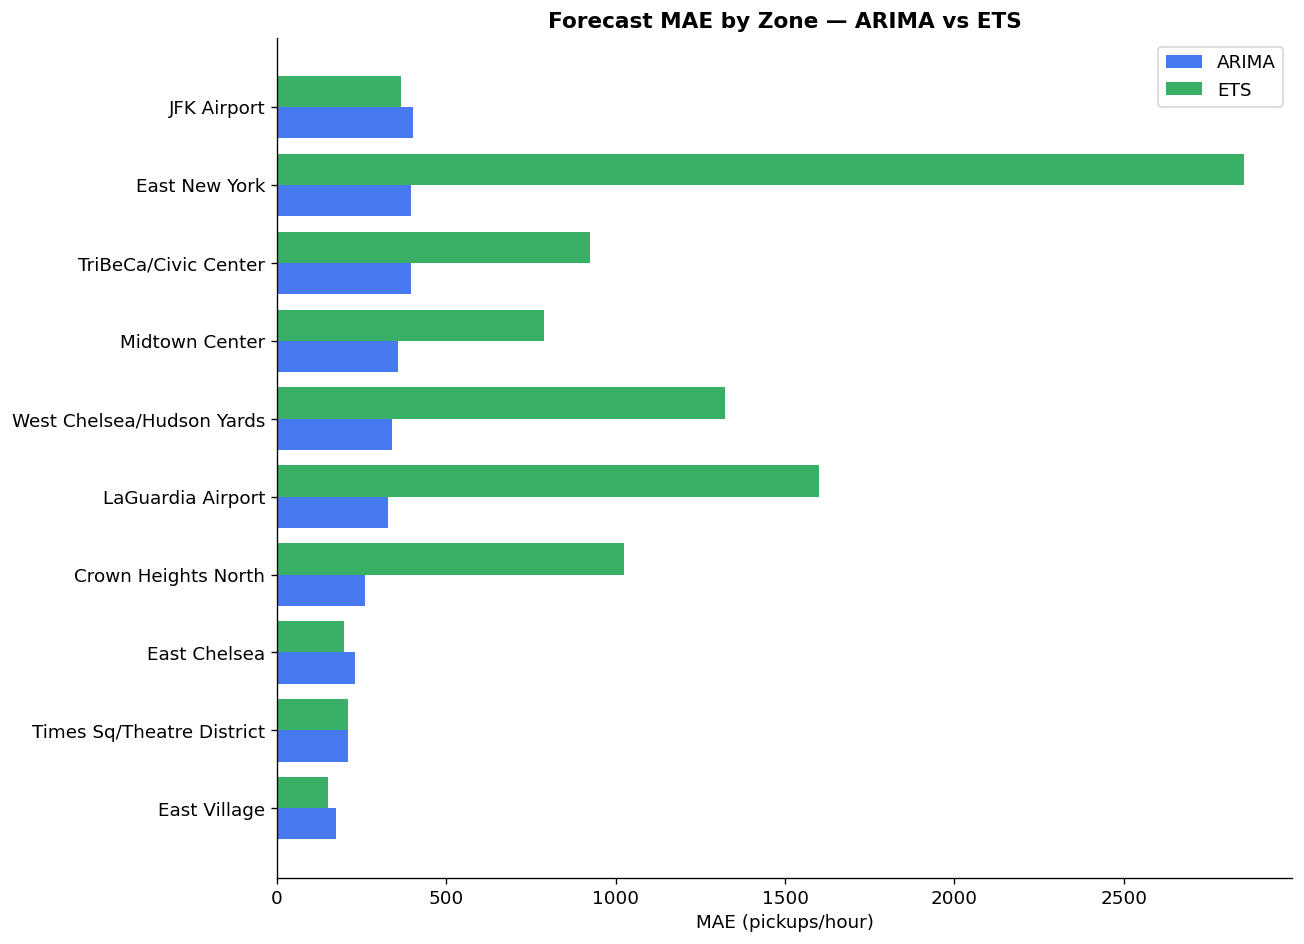

In [14]:
# Visualize MAE comparison ARIMA vs ETS per zone
pivot = eval_df.pivot(index='zone_name', columns='model', values='mae')
pivot = pivot.sort_values('ARIMA', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
x = np.arange(len(pivot))
width = 0.4
ax.barh(x - width/2, pivot['ARIMA'], width, label='ARIMA', color=PALETTE[0], alpha=0.85)
ax.barh(x + width/2, pivot['ETS'],   width, label='ETS',   color=PALETTE[1], alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('MAE (pickups/hour)')
ax.set_title('Forecast MAE by Zone — ARIMA vs ETS', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/forecasting/01_mae_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 6 · Forecast vs Actual — Top 6 Zones

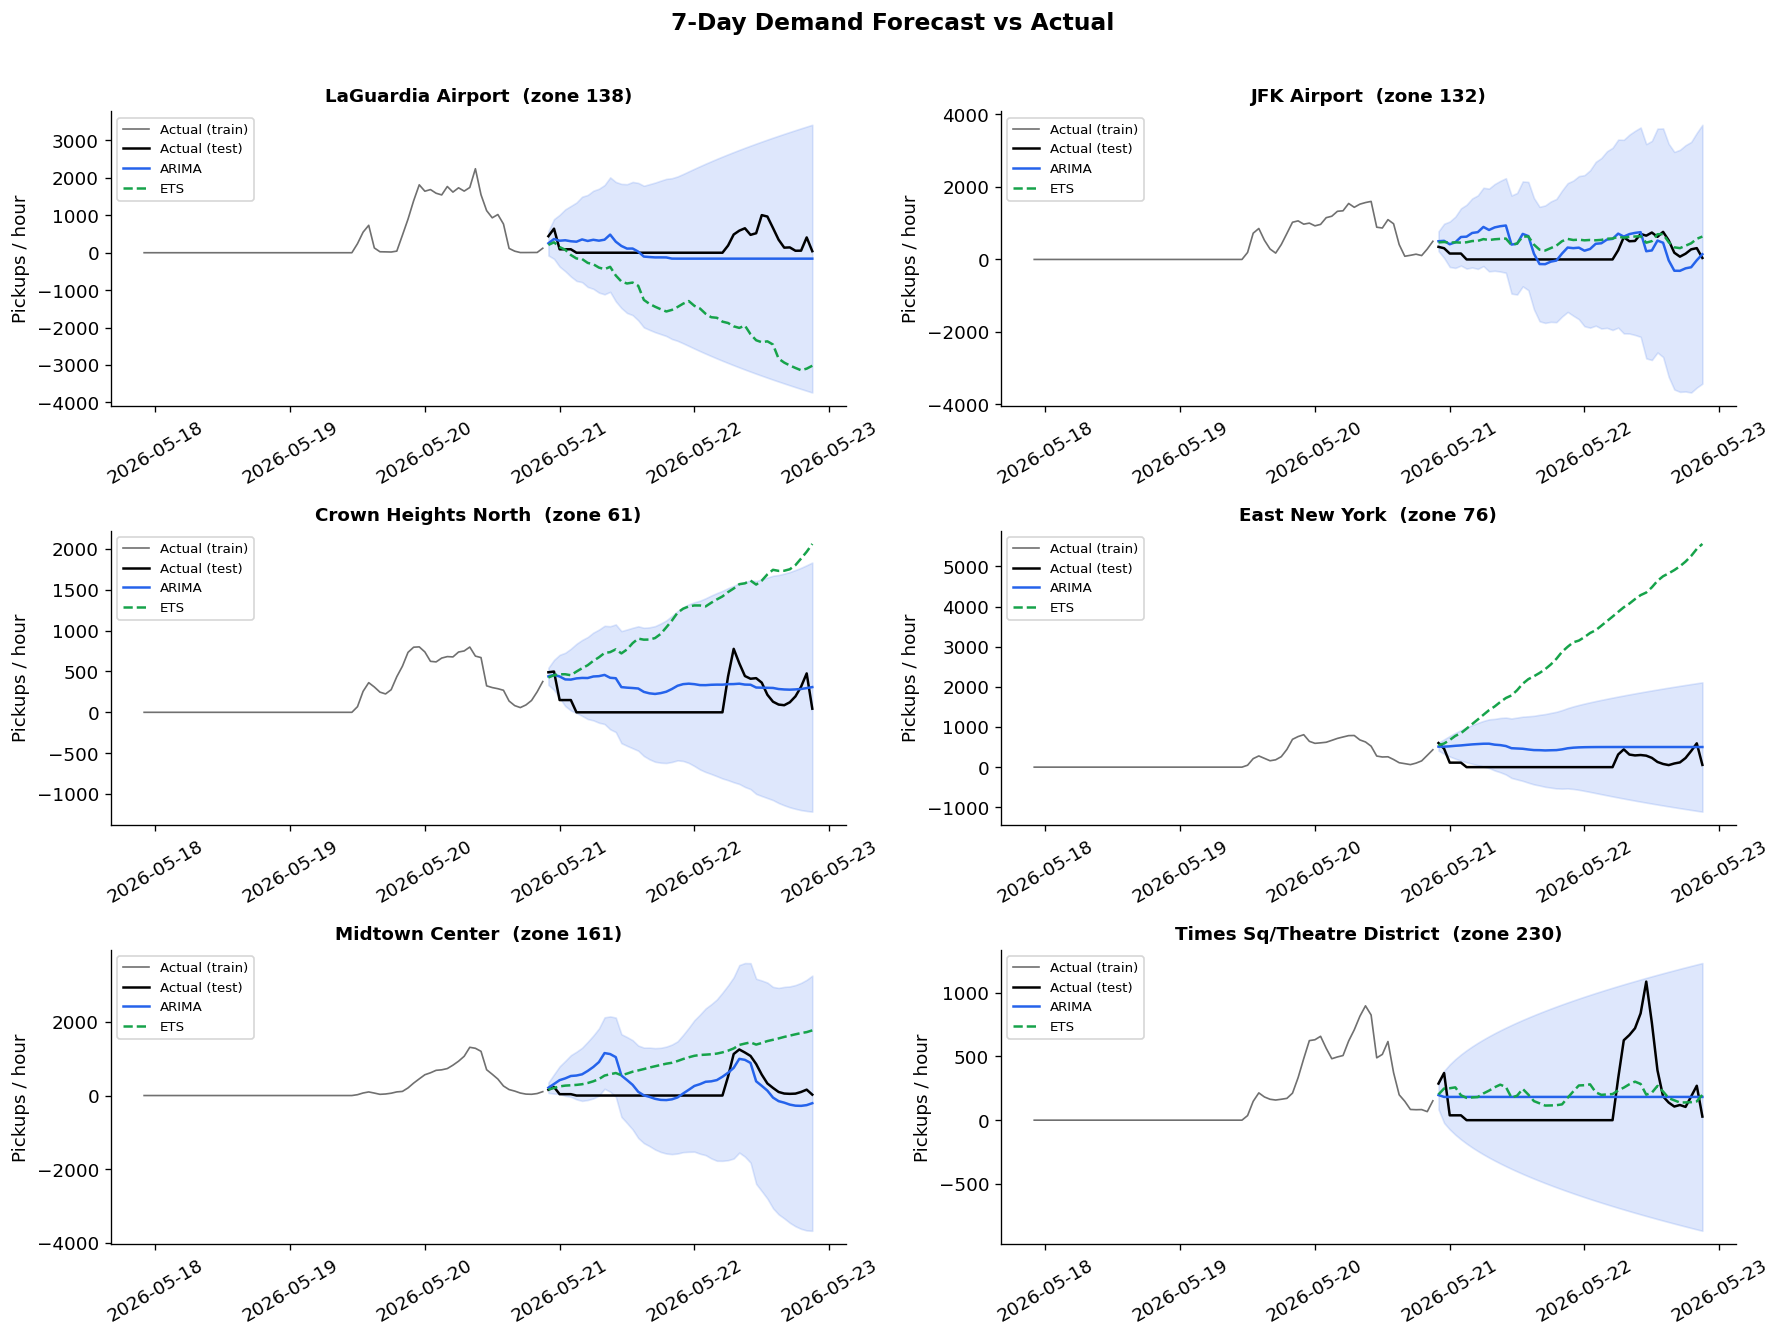

In [15]:
# Pick top 6 zones by training-set total demand
top6 = train.sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 11))
for ax, zid in zip(axes.flat, top6):
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]

    # Plot last 3 days of train + full test
    hist = train[zid].iloc[-72:]
    ax.plot(hist.index, hist.values, color='#333', lw=1, label='Actual (train)', alpha=0.7)
    ax.plot(test.index, test[zid].values, color='#000', lw=1.5, label='Actual (test)')

    if zid in arima_preds:
        p = arima_preds[zid]
        ax.plot(p.index, p['forecast'], color=PALETTE[0], lw=1.5, label='ARIMA')
        ax.fill_between(p.index, p['lower'], p['upper'], color=PALETTE[0], alpha=0.15)
    if zid in ets_preds:
        p = ets_preds[zid]
        ax.plot(p.index, p['forecast'], color=PALETTE[1], lw=1.5, label='ETS', linestyle='--')

    ax.set_title(f'{name}  (zone {zid})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pickups / hour')
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('7-Day Demand Forecast vs Actual', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/forecasting/02_forecast_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()

## 7 · Export Trained Models

Each fitted ARIMA and ETS is pickled to `models/` so the Spark Forecasting job can `joblib.load(...)` them at runtime. Also write a manifest mapping `zone_id → model path` for Spark to discover what's available.

In [16]:
manifest = []
for zid, model in arima_models.items():
    path = f'models/arima_zone_{zid}.pkl'
    joblib.dump(model, path)
    manifest.append({'zone_id': zid, 'model': 'ARIMA', 'path': path,
                     'mae': eval_df.query('zone_id==@zid and model=="ARIMA"').iloc[0]['mae']})

for zid, model in ets_models.items():
    path = f'models/ets_zone_{zid}.pkl'
    joblib.dump(model, path)
    manifest.append({'zone_id': zid, 'model': 'ETS', 'path': path,
                     'mae': eval_df.query('zone_id==@zid and model=="ETS"').iloc[0]['mae']})

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv('models/manifest.csv', index=False)

total_mb = sum(os.path.getsize(p) for p in manifest_df['path']) / (1024 * 1024)
print(f'Exported {len(manifest_df)} models  ({total_mb:.1f} MB total)')
print(f'Manifest: models/manifest.csv')

Exported 20 models  (98.4 MB total)
Manifest: models/manifest.csv


## 8 · Write Forecasts to `forecast_results`

For each zone, pick the better model (lower MAE) and write its 7-day prediction. This is the table Grafana's "Forecast vs Actual" panel reads from.

In [17]:
create_sql = """
CREATE TABLE IF NOT EXISTS forecast_results (
    id                BIGSERIAL,
    forecast_time     TIMESTAMPTZ NOT NULL,
    zone_id           INTEGER REFERENCES taxi_zones(zone_id),
    predicted_demand  FLOAT,
    lower_bound       FLOAT,
    upper_bound       FLOAT,
    model_name        VARCHAR(30),
    mae               FLOAT,
    PRIMARY KEY (id, forecast_time)
);
SELECT create_hypertable('forecast_results', 'forecast_time',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
CREATE INDEX IF NOT EXISTS idx_forecast_zone
    ON forecast_results (zone_id, forecast_time DESC);
"""
with engine.connect() as conn:
    for stmt in create_sql.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print('forecast_results hypertable ready.')

forecast_results hypertable ready.


In [18]:
# Per zone: choose the model with lower MAE
best = (eval_df.sort_values('mae')
              .drop_duplicates('zone_id', keep='first')
              .set_index('zone_id'))

rows = []
for zid, info in best.iterrows():
    preds = (arima_preds if info['model'] == 'ARIMA' else ets_preds).get(zid)
    if preds is None:
        continue
    for ts, row in preds.iterrows():
        rows.append({
            'forecast_time':    ts,
            'zone_id':          int(zid),
            'predicted_demand': float(row['forecast']),
            'lower_bound':      float(row['lower']),
            'upper_bound':      float(row['upper']),
            'model_name':       info['model'],
            'mae':              float(info['mae']),
        })

out_df = pd.DataFrame(rows)
out_df.to_sql('forecast_results', engine, if_exists='append', index=False)
print(f'Written {len(out_df):,} forecast rows '
      f'({out_df.zone_id.nunique()} zones × {HORIZON}h horizon)')

Written 480 forecast rows (10 zones × 48h horizon)


## 9 · Summary Findings

In [19]:
print('=' * 60)
print('FORECASTING SUMMARY FINDINGS')
print('=' * 60)

avg = eval_df.groupby('model')[['mae', 'rmse', 'mape']].mean()
winners = best['model'].value_counts()

best_zone = eval_df.loc[eval_df['mae'].idxmin()]
worst_zone = eval_df.loc[eval_df['mae'].idxmax()]

print(f"""
1. MODEL COMPARISON (average across {len(zone_ids)} zones):
   ARIMA:  MAE={avg.loc['ARIMA','mae']:.2f}  RMSE={avg.loc['ARIMA','rmse']:.2f}  MAPE={avg.loc['ARIMA','mape']:.1f}%
   ETS:    MAE={avg.loc['ETS','mae']:.2f}  RMSE={avg.loc['ETS','rmse']:.2f}  MAPE={avg.loc['ETS','mape']:.1f}%

2. PER-ZONE WINNERS:
   ARIMA chosen for: {winners.get('ARIMA', 0)} zones
   ETS   chosen for: {winners.get('ETS', 0)} zones

3. BEST FORECAST (lowest MAE):
   {best_zone['zone_name']:30s} {best_zone['model']}  MAE={best_zone['mae']:.2f}

4. HARDEST ZONE TO FORECAST (highest MAE):
   {worst_zone['zone_name']:30s} {worst_zone['model']}  MAE={worst_zone['mae']:.2f}

5. OUTPUT FILES:
   outputs/forecasting/01_mae_comparison.png
   outputs/forecasting/02_forecast_vs_actual.png
   models/arima_zone_*.pkl    ({len(arima_models)} files)
   models/ets_zone_*.pkl      ({len(ets_models)} files)
   models/manifest.csv

6. DB:
   forecast_results: {len(out_df):,} new rows
""")

FORECASTING SUMMARY FINDINGS

1. MODEL COMPARISON (average across 10 zones):
   ARIMA:  MAE=309.41  RMSE=354.41  MAPE=190.9%
   ETS:    MAE=943.60  RMSE=1079.23  MAPE=873.8%

2. PER-ZONE WINNERS:
   ARIMA chosen for: 6 zones
   ETS   chosen for: 4 zones

3. BEST FORECAST (lowest MAE):
   East Village                   ETS  MAE=149.51

4. HARDEST ZONE TO FORECAST (highest MAE):
   East New York                  ETS  MAE=2855.19

5. OUTPUT FILES:
   outputs/forecasting/01_mae_comparison.png
   outputs/forecasting/02_forecast_vs_actual.png
   models/arima_zone_*.pkl    (10 files)
   models/ets_zone_*.pkl      (10 files)
   models/manifest.csv

6. DB:
   forecast_results: 480 new rows



In [20]:
import os, shutil
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=False)

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1

# Also sync trained models (they live in models/, not outputs/)
if os.path.exists('models'):
    drive_models = os.path.join(DRIVE_OUTPUTS, 'forecasting/models')
    os.makedirs(drive_models, exist_ok=True)
    for f in os.listdir('models'):
        shutil.copy2(f'models/{f}', f'{drive_models}/{f}')
        n += 1

print(f'Synced {n} files to {DRIVE_OUTPUTS}')

Mounted at /content/drive
Synced 23 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs


In [21]:
import os
forecasting_dir = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs/forecasting'
for root, _, files in os.walk(forecasting_dir):
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f'  {os.path.relpath(os.path.join(root, f), forecasting_dir)}  ({size:.0f} KB)')

  01_mae_comparison.png  (74 KB)
  02_forecast_vs_actual.png  (331 KB)
  models/arima_zone_132.pkl  (49113 KB)
  models/arima_zone_138.pkl  (12644 KB)
  models/arima_zone_161.pkl  (12643 KB)
  models/arima_zone_230.pkl  (455 KB)
  models/arima_zone_231.pkl  (310 KB)
  models/arima_zone_246.pkl  (636 KB)
  models/arima_zone_61.pkl  (11717 KB)
  models/arima_zone_68.pkl  (200 KB)
  models/arima_zone_76.pkl  (12644 KB)
  models/arima_zone_79.pkl  (200 KB)
  models/ets_zone_132.pkl  (25 KB)
  models/ets_zone_138.pkl  (25 KB)
  models/ets_zone_161.pkl  (25 KB)
  models/ets_zone_230.pkl  (25 KB)
  models/ets_zone_231.pkl  (25 KB)
  models/ets_zone_246.pkl  (25 KB)
  models/ets_zone_61.pkl  (25 KB)
  models/ets_zone_68.pkl  (25 KB)
  models/ets_zone_76.pkl  (25 KB)
  models/ets_zone_79.pkl  (25 KB)
  models/manifest.csv  (1 KB)
